Confusion Matrix:
[[ 7  0  0]
 [ 0 21  0]
 [ 1  0 31]]

Classification Report:
              precision    recall  f1-score   support

        Alto       0.88      1.00      0.93         7
        Bajo       1.00      1.00      1.00        21
       Medio       1.00      0.97      0.98        32

    accuracy                           0.98        60
   macro avg       0.96      0.99      0.97        60
weighted avg       0.99      0.98      0.98        60


🎯 Predicción personalizada → Altura: 198 cm, Peso: 92 kg, Prom. puntos: 17
   → Categoría predicha: Alto


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/basketball_plot.png'

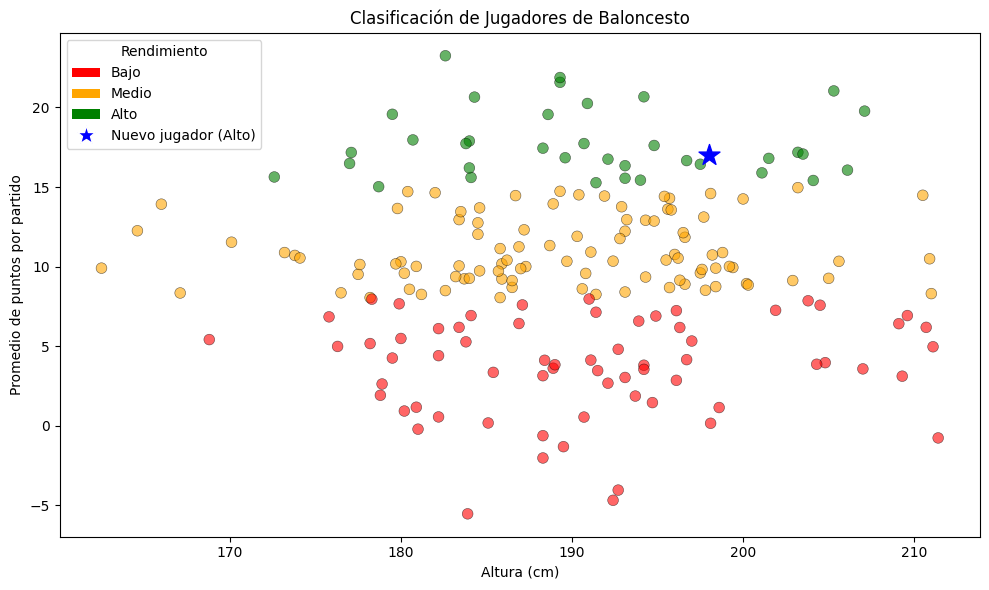

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Clase que representa a un jugador
class BasketballPlayer:
    def __init__(self, height, weight, avg_points, performance):
        self.height = height            # en cm
        self.weight = weight            # en kg
        self.avg_points = avg_points    # promedio de puntos por partido
        self.performance = performance  # "Bajo", "Medio", "Alto"

    def to_vector(self):
        return [self.height, self.weight, self.avg_points]


# Generador de datos sintéticos
class BasketballDataGenerator:
    def __init__(self, num_samples=200):
        self.num_samples = num_samples

    def generate(self):
        heights = np.random.normal(190, 10, self.num_samples)
        weights = np.random.normal(85, 10, self.num_samples)
        avg_points = np.random.normal(10, 5, self.num_samples)

        players = []
        for h, w, p in zip(heights, weights, avg_points):
            if p < 8:
                performance = "Bajo"
            elif p <= 15:
                performance = "Medio"
            else:
                performance = "Alto"

            players.append(BasketballPlayer(
                height=round(h, 1),
                weight=round(w, 1),
                avg_points=round(p, 2),
                performance=performance
            ))

        return players


# Clasificador con árbol de decisión
class BasketballPerformanceClassifier:
    def __init__(self):
        self.model = DecisionTreeClassifier()

    def fit(self, players):
        X = [p.to_vector() for p in players]
        y = [p.performance for p in players]
        self.model.fit(X, y)

    def predict(self, height, weight, avg_points):
        vector = [[height, weight, avg_points]]
        return self.model.predict(vector)[0]

    def evaluate(self, players):
        X = [p.to_vector() for p in players]
        y_true = [p.performance for p in players]
        y_pred = self.model.predict(X)

        print("Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred))


# Clase para ejecutar el ejemplo con matplotlib
class BasketballPredictionExample:
    def run(self):
        # 1. Generar datos
        generator = BasketballDataGenerator(num_samples=200)
        players = generator.generate()

        # 2. Dividir en entrenamiento y prueba
        train_players, test_players = train_test_split(players, test_size=0.3, random_state=42)

        # 3. Entrenar el clasificador
        classifier = BasketballPerformanceClassifier()
        classifier.fit(train_players)

        # 4. Evaluar el clasificador
        classifier.evaluate(test_players)

        # 5. Predicción personalizada
        new_height = 198
        new_weight = 92
        new_points = 17
        prediction = classifier.predict(new_height, new_weight, new_points)
        print(f"\n🎯 Predicción personalizada → Altura: {new_height} cm, Peso: {new_weight} kg, Prom. puntos: {new_points}")
        print(f"   → Categoría predicha: {prediction}")

        # 6. Visualización con matplotlib
        df = pd.DataFrame({
            "height": [p.height for p in players],
            "avg_points": [p.avg_points for p in players],
            "performance": [p.performance for p in players]
        })

        color_map = {"Bajo": "red", "Medio": "orange", "Alto": "green"}
        colors = df["performance"].map(color_map)

        plt.figure(figsize=(10, 6))
        plt.scatter(df["height"], df["avg_points"], c=colors, alpha=0.6, edgecolors="k", linewidths=0.4, s=60)

        # Marcar el jugador nuevo
        plt.scatter(new_height, new_points, color="blue", s=250, marker="*",
                    zorder=5, label=f"Nuevo jugador ({prediction})")

        # Leyenda manual para rendimiento
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor="red", label="Bajo"),
            Patch(facecolor="orange", label="Medio"),
            Patch(facecolor="green", label="Alto"),
            plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="blue",
                       markersize=14, label=f"Nuevo jugador ({prediction})")
        ]
        plt.legend(handles=legend_elements, title="Rendimiento")

        plt.xlabel("Altura (cm)")
        plt.ylabel("Promedio de puntos por partido")
        plt.title("Clasificación de Jugadores de Baloncesto")
        plt.tight_layout()
        plt.savefig("/mnt/user-data/outputs/basketball_plot.png", dpi=150)
        plt.show()
        print("\n📊 Gráfico guardado como 'basketball_plot.png'")


# Ejecutar el ejemplo
example = BasketballPredictionExample()
example.run()